In [1]:
%matplotlib widget
import os
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. STYLE CONFIGURATION
# ============================================================

poster_style = {
    "figsize": (3, 3),
    "dpi": 300,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 2,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "--", "-.", ":"]
}

# ============================================================
# 2. LOAD RAMAN TXT SPECTRA
# ============================================================

# You can add multiple parent directories here. The script will search them.
target_dirs = [
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260818_FilledCNTs_CF_P2_F005LP_F006WA_F007WA"
]

raman_spectra = {}

for folder in target_dirs:
    print(f"\nReading folder: {folder}")
    
    # os.walk allows it to look inside subfolders (e.g., wavelength1, wavelength2)
    for root, dirs, files in os.walk(folder):
        for file in files:
            if not file.lower().endswith(".txt"):
                continue
            
            path = os.path.join(root, file)
            
            try:
                # Xplora Raman files usually use tabs, might have comments
                df = pd.read_csv(
                    path, 
                    sep="\t", 
                    comment="#", 
                    header=None, 
                    encoding="latin1",
                    usecols=[0, 1] # Ensure we only grab X and Y if there's extra junk
                )
                
                df.columns = ["RamanShift", "Intensity"]
                
                # Convert to numeric, drop NaNs, and sort by shift
                df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
                df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
                df = df.dropna().sort_values("RamanShift").reset_index(drop=True)
                
                raman_spectra[file] = df
                print(f"Loaded: {file} ({len(df)} points)")
                
            except Exception as e:
                print(f"Could not load {file}: {e}")

print("\n--- Available spectra ---")
for name in raman_spectra:
    print('"' + name + '",')


# ============================================================
# 4. TRIM SPECTRA (Make regions equal)
# ============================================================

def TrimSpectra(spectra_input, xmin, xmax):
    """
    Cuts the spectra down to a specific Raman shift window 
    so different scanned regions can be compared equally.
    """
    trimmed = {}
    for name, df in spectra_input.items():
        mask = (df["RamanShift"] >= xmin) & (df["RamanShift"] <= xmax)
        trimmed[name] = df[mask].copy().reset_index(drop=True)
        print(f"Trimmed {name} to {xmin}-{xmax} cm-1")
    return trimmed

# Optional: Apply trimming to match regions (e.g., just looking at 1000 - 1800 cm-1)


# ============================================================
# 5. NORMALIZATION FUNCTION
# ============================================================

def NormalizeSpectra(spectra_input, xmin=None, xmax=None, mode="M"):
    """
    Normalize spectra based on a specific window.
    M = maximum (Peak)
    I = integral (Area)
    V = valley/minimum
    """
    normalized = {}
    
    for name, df in spectra_input.items():
        df_norm = df.copy()
        
        X = df_norm["RamanShift"].values
        Y = df_norm["Intensity"].values
        
        # If no window is given, use the whole range
        if xmin is not None and xmax is not None:
            mask = (X >= xmin) & (X <= xmax)
        else:
            mask = np.ones_like(X, dtype=bool)
            
        X_window = X[mask]
        Y_window = Y[mask]
        
        if len(X_window) == 0:
            print(f"No points in normalization range for {name}")
            continue
            
        if mode.upper() == "M":
            factor = np.max(Y_window)
        elif mode.upper() == "I":
            factor = np.trapezoid(Y_window, X_window)
        elif mode.upper() == "V":
            factor = np.min(Y_window)
        else:
            raise ValueError("Mode must be 'M', 'I', or 'V'")
            
        if factor == 0:
            print(f"Normalization factor is zero for {name}")
            continue
            
        df_norm["Intensity"] = Y / factor
        normalized[name] = df_norm
        print(f"Normalized ({mode}): {name} (factor = {factor:.4g})")
        
    return normalized

# ============================================================
# 6. PLOT FUNCTION
# ============================================================

def PlotRaman(spectra_dict, spectra_names, style=poster_style, offset_step=0.0, 
              xmin=None, xmax=None, ymin=None, ymax=None, 
              custom_labels=None):
    
    plt.figure(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({
        "font.size": style["font_size"],
        "font.family": style["font_family"]
    })
    
    colors = style.get("colors")
    
    for i, name in enumerate(spectra_names):
        if name not in spectra_dict:
            print(f"WARNING: {name} not found in dictionary")
            continue
            
        df = spectra_dict[name]
        
        # Apply custom label if provided, else use filename
        label = custom_labels[i] if custom_labels and i < len(custom_labels) else name
        
        X = df["RamanShift"].values
        Y = df["Intensity"].values + (i * offset_step)
        
        c = colors[i % len(colors)] if colors else None
        
        plt.plot(X, Y, label=label, linewidth=style["line_width"], color=c)
        # plt.scatter(X, Y, s=0.05, color=c) # Uncomment if you want scatter points too

    plt.xlabel("Raman shift (cm$^{-1}$)", fontsize=style["label_size"])
    plt.ylabel("Intensity (a.u.)", fontsize=style["label_size"])
    plt.title("Raman Spectra", fontsize=style["title_size"])
    
    if xmin is not None or xmax is not None:
        plt.xlim(xmin, xmax)
    if ymin is not None or ymax is not None:
        plt.ylim(ymin, ymax)
        
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=style["legend_size"])
    plt.tight_layout()
    plt.show()

# ============================================================
# 3. SELECT YOUR EXPERIMENTAL SPECTRA
# ============================================================

# Copy and paste the filenames printed above that you actually want to analyze
SpecAlles = [
    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt",
    "260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    "260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt",
    "260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
]


Reading folder: H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260818_FilledCNTs_CF_P2_F005LP_F006WA_F007WA
Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Could not load Samples.txt: Usecols do not match columns, columns expected but not found: [1]
Loaded: 260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (950 points)
Loaded: 260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt (950 points)
Loaded: 260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt (950 points)
Loaded: 260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (950 points)
Loaded: 260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt (950 points)
Loaded: 260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt (950 points)
Loaded: 260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (950 poi

# Analysis for 532nm different regions> RBM, GBand, 2DBand...

Normalized (M): 260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt (factor = 4749)
Normalized (M): 260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt (factor = 3106)
Normalized (M): 260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt (factor = 5073)
Normalized (M): 260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt (factor = 3333)


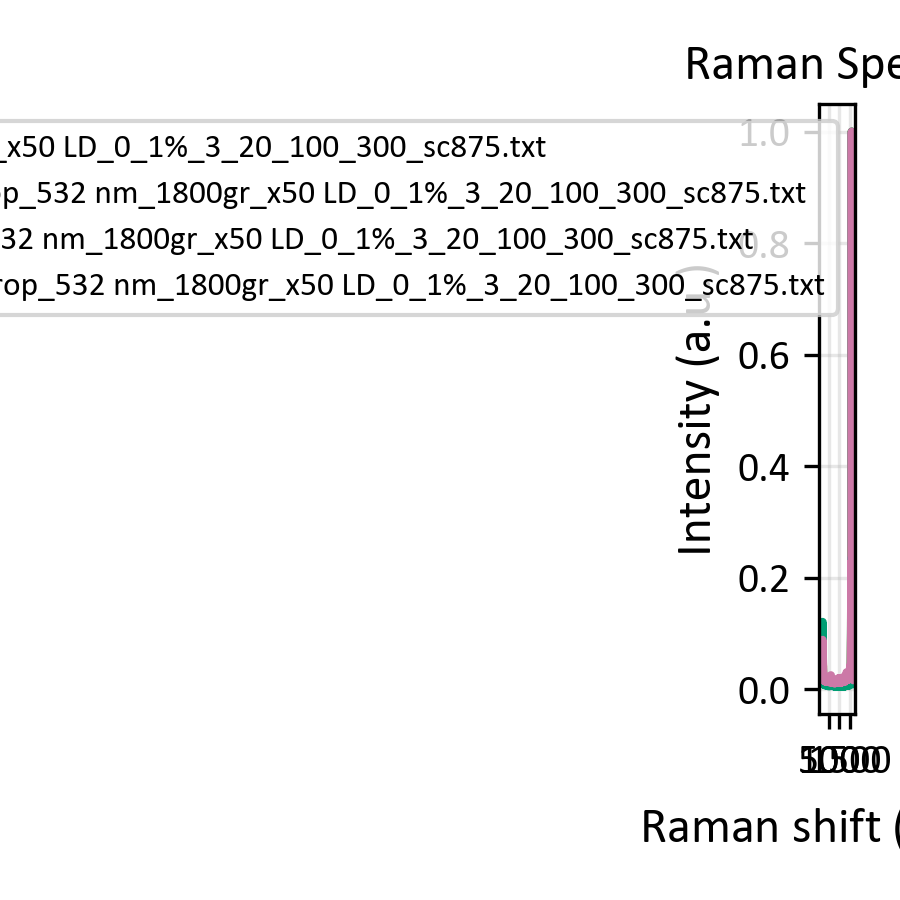

In [2]:
Spec532nm = [

## From these four it seems that F005 and F006 are a bit Gband upshifted, also there are additional Raman peaks fro F006WA sample.
    
    "260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",

#    "260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    
#    "260818_P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
]


selected_spectra = Spec532nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None
)

Normalized (M): 260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt (factor = 5437)
Normalized (M): 260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt (factor = 6508)
Normalized (M): 260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt (factor = 5228)
Normalized (M): 260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt (factor = 3743)


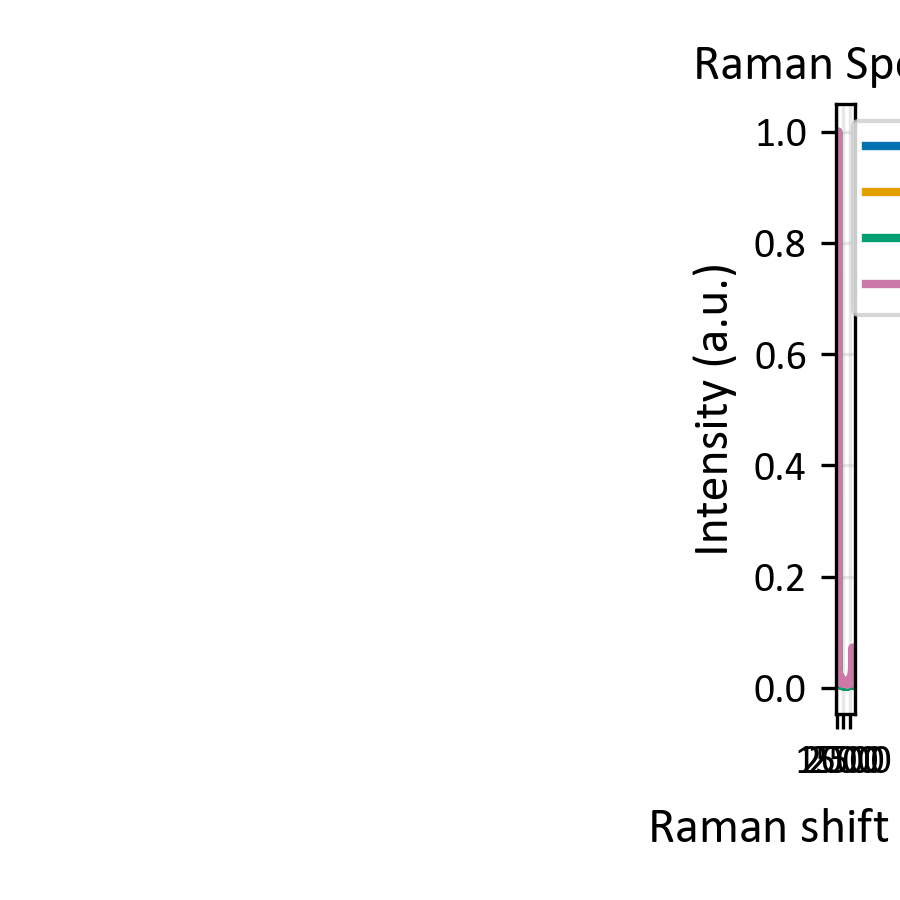

In [3]:
Spec532nm = [

## From these four it seems that F005 and F006 are a bit Gband upshifted, also there are additional Raman peaks fro F006WA sample.
    
    #"260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    #"260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    #"260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    #"260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",

    "260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    
#    "260818_P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
]


selected_spectra = Spec532nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None
)

Normalized (M): 260818_P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (factor = 1.519e+04)
Normalized (M): 260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (factor = 2.7e+04)
Normalized (M): 260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (factor = 1.804e+04)
Normalized (M): 260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt (factor = 1.638e+04)


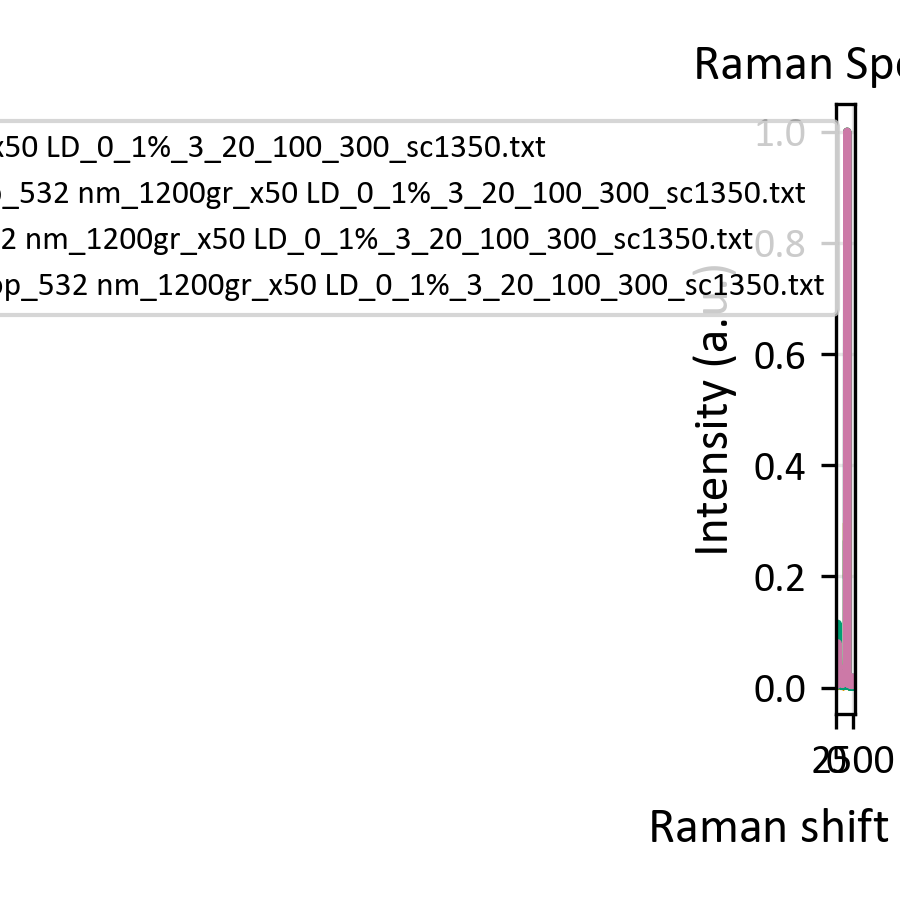

In [4]:
Spec532nm = [

## From these four it seems that F005 and F006 are a bit Gband upshifted, also there are additional Raman peaks fro F006WA sample.
    
    #"260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    #"260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    #"260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",
    #"260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc875.txt",

    #"260818_P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    #"260818_F007WA_1BrC18@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    #"260818_F005LP_6FBz@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    #"260818_F006WA_phDADQ@P2_CFDrop_532 nm_1800gr_x50 LD_0_1%_3_20_100_300_sc2150.txt",
    
    "260818_P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_F005LP_6FBz@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_532 nm_1200gr_x50 LD_0_1%_3_20_100_300_sc1350.txt",
]


selected_spectra = Spec532nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None
)

# Analysis for 638nm different regions> RBM, GBand, 2DBand...

Normalized (M): 260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt (factor = 8584)
Normalized (M): 260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt (factor = 1.359e+04)


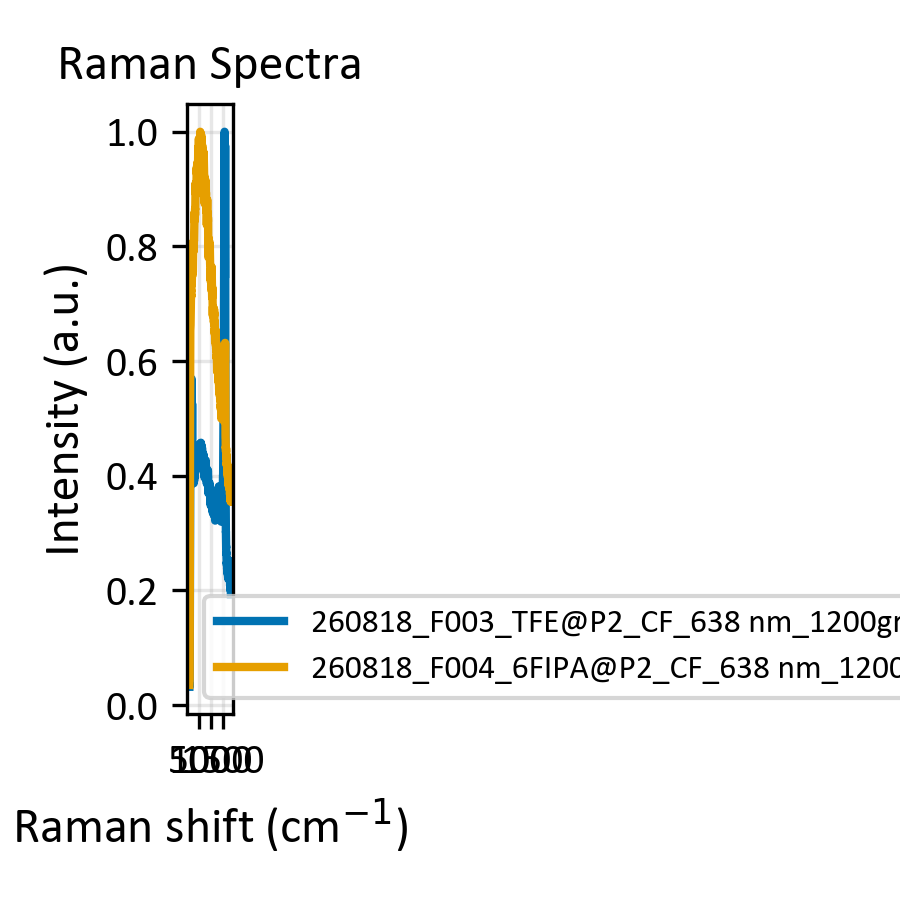

In [5]:
Spec638nm = [

    "260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt",
    "260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

#    "260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

#    "260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",

#    "260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    

]


selected_spectra = Spec638nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.0,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None
)

Normalized (M): 260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt (factor = 1770)
Normalized (M): 260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt (factor = 415.3)
Normalized (M): 260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt (factor = 574.1)
Normalized (M): 260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt (factor = 463.6)


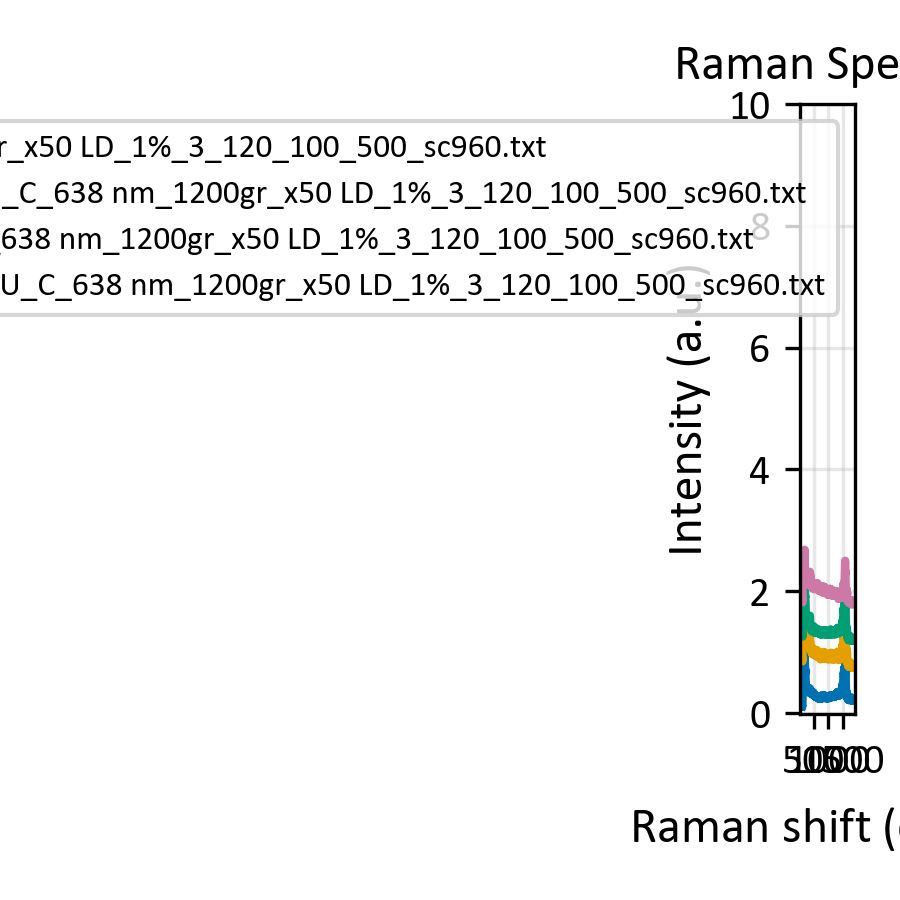

In [6]:
Spec638nm = [

#    "260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt",
#    "260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

    "260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
    "260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

#    "260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",

#    "260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    

]


selected_spectra = Spec638nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=1250, xmax=1750, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.5,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymin=None,
    ymax=10
)

Normalized (M): 260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 625.9)
Normalized (M): 260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 439)
Normalized (M): 260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 470.4)
Normalized (M): 260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 588.6)
Normalized (M): 260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 6.299)
Normalized (M): 260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 5.496)
Normalized (M): 260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 4.457)
Normalized (M): 260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt (factor = 3.519)


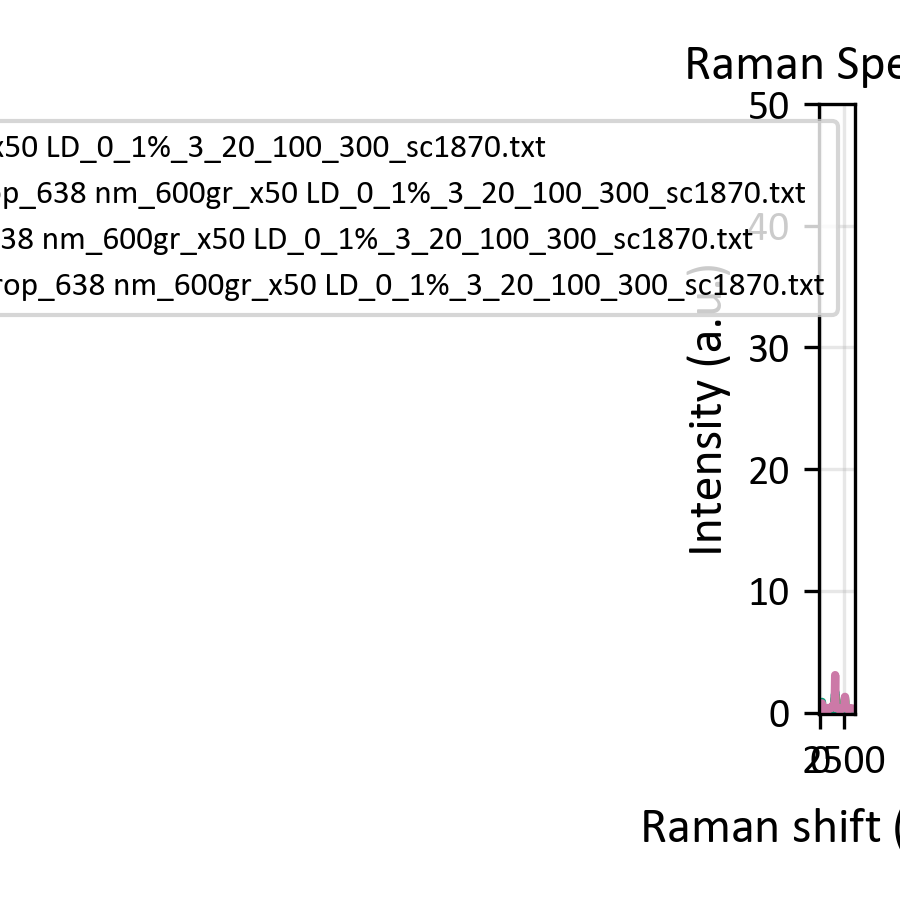

In [7]:
Spec638nm = [

#    "260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt",
#    "260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

#    "260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

    "260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",

#    "260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    

]


selected_spectra = Spec638nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=1260, xmax=1350, mode="M")
selected_spectra = NormalizeSpectra(selected_spectra, xmin=2500, xmax=3000, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.1,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymin=None,
    ymax=50
)

Normalized (M): 260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt (factor = 306.4)
Normalized (M): 260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt (factor = 416.2)
Normalized (M): 260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt (factor = 472)
Normalized (M): 260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt (factor = 310.8)


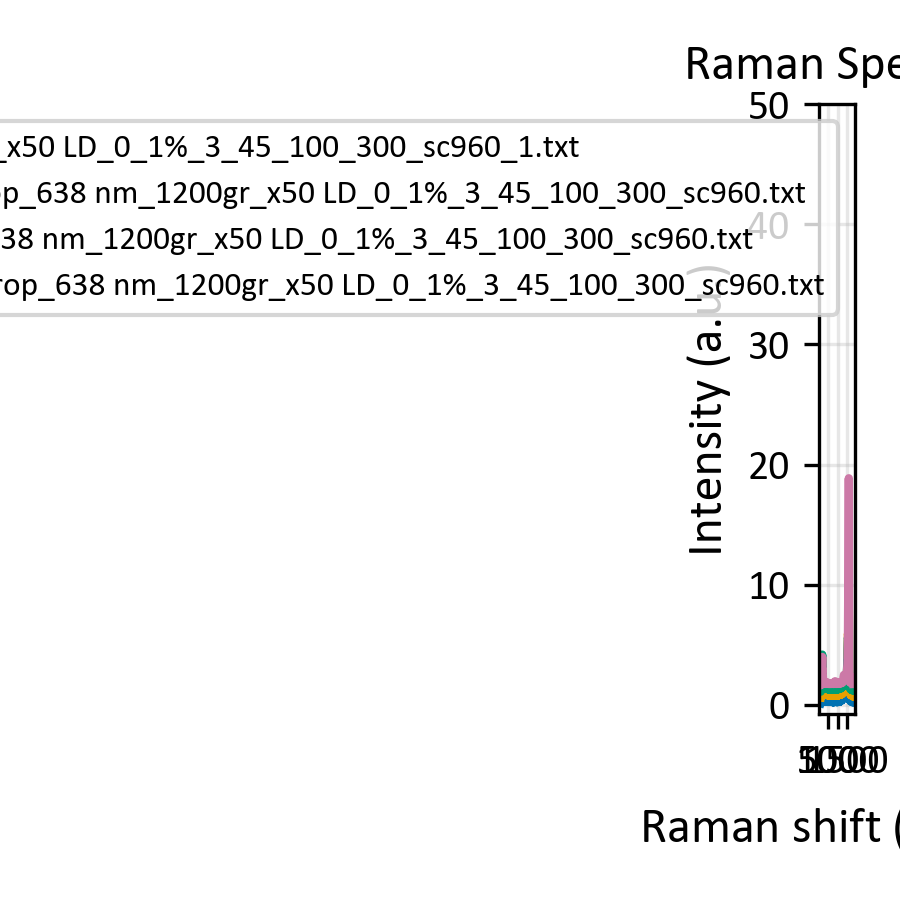

In [8]:
Spec638nm = [

#    "260818_F003_TFE@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960_01.txt",
#    "260818_F004_6FIPA@P2_CF_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

#    "260818_P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F007WA_1BrC18@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F005LP_6FBz@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",
#    "260818_F006WA_phDADQ@P2_DGU_C_638 nm_1200gr_x50 LD_1%_3_120_100_500_sc960.txt",

#    "260818_P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F005LP_6FBz@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",
#    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_600gr_x50 LD_0_1%_3_20_100_300_sc1870.txt",

    "260818_P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960_1.txt",
    "260818_F007WA_1BrC18@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    "260818_F005LP_6FBz@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    "260818_F006WA_phDADQ@P2_CFDrop_638 nm_1200gr_x50 LD_0_1%_3_45_100_300_sc960.txt",
    

]


selected_spectra = Spec638nm
selected_spectra = {name: raman_spectra[name] for name in selected_spectra if name in raman_spectra}
#selected_spectra = TrimSpectra(selected_spectra, xmin=800, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=1260, xmax=1350, mode="M")


# Optional: Provide cleaner names for the legend based on the filenames
clean_labels = [
 
]

# Plot the final processed data
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_spectra,
    custom_labels=None,
    offset_step=0.5,          # Shifts each spectrum up by 1.2 for easy stacking
    xmin=None,
    xmax=None,
    ymax=50

)